# 🏃 02-动量族与加速方法

> 目标：理解**动量 = 对历史梯度做指数滑动平均（EMA）**，为什么能压震荡、穿峡谷、过鞍点；
> 以及 Nesterov（NAG）「先看未来再迈步」的差别。

## §1 病态曲率：峡谷地形的困境

设 $f(w) = w_1^2 + 40\,w_2^2$：$w_2$ 方向梯度大 40 倍（陡壁），$w_1$ 方向平坦（峡谷底）。
SGD 在陡壁上大步来回震荡、沿谷底前进缓慢。

**动量直觉**：把每次梯度的方向做 EMA，陡壁上的正负梯度相互抵消，谷底方向被累积 → 前进更稳更快。

$$v_t = \beta v_{t-1} + g_t, \qquad w_t = w_{t-1} - \eta v_t, \qquad \beta = 0.9$$

> $v$ 是「速度」，$\beta$ 是摩擦系数（保留多少旧速度）。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def sgd(w, g, t, lr=0.01):
    return w - lr * g, None

def momentum(w, g, t, lr=0.01, beta=0.9, v=None):
    v = beta * v + g if v is not None else g
    return w - lr * v, v

def nesterov(w, g, t, lr=0.01, beta=0.9, v=None):
    # 前瞻：先用当前速度冲一步，在那里的梯度作为真实梯度
    v_prev = beta * v if v is not None else 0.0
    lookahead = w - lr * beta * v_prev
    # 简化实现：直接用峡谷梯度函数在 lookahead 处重算
    g_ahead = canyon_grad(lookahead)
    v = beta * v + g_ahead if v is not None else g_ahead
    return w - lr * v, v

def canyon_grad(w):
    return np.array([2.0 * w[0], 80.0 * w[1]])  # 峡谷：y 方向陡 40 倍

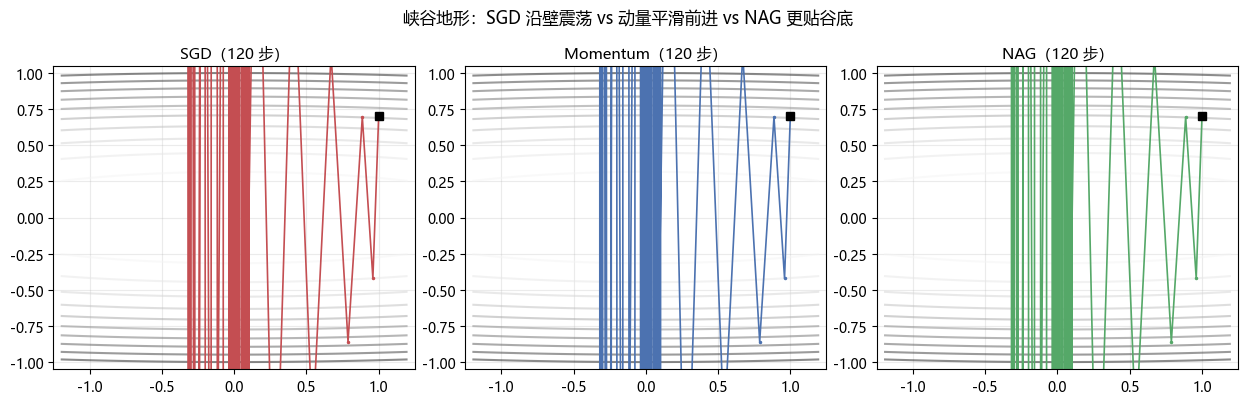

sgd       终点 |w| = 0.0075
mom       终点 |w| = 0.0015
nesterov  终点 |w| = 19463380197624.2383


In [2]:
# ---------- 实验 1：峡谷地形收敛轨迹对比 ----------
w0 = np.array([1.0, 0.7])

def run(opt, steps=120, lr=0.02, beta=0.9):
    w = w0.copy(); v = None; pts = [w.copy()]
    for t in range(steps):
        g = canyon_grad(w)
        if opt == 'sgd':
            w, v = sgd(w, g, t, lr)
        elif opt == 'mom':
            w, v = momentum(w, g, t, lr, beta, v)
        else:
            w, v = nesterov(w, g, t, lr, beta, v)
        pts.append(w.copy())
    return np.array(pts)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4))
w1 = np.linspace(-1.2, 1.2, 200); w2 = np.linspace(-1.0, 1.0, 200)
W1, W2 = np.meshgrid(w1, w2)
Z = W1**2 + 40 * W2**2
for ax, (name, col) in zip(axes, [('SGD', '#C44E52'), ('Momentum', '#4C72B0'), ('NAG', '#55A868')]):
    ax.contour(W1, W2, Z, levels=12, cmap='Greys', alpha=0.5)
    pts = run(name)
    ax.plot(pts[:, 0], pts[:, 1], '.-', color=col, lw=1.2, ms=3)
    ax.plot(w0[0], w0[1], 'ks', ms=6)
    ax.set_title(f'{name}（120 步）', fontsize=11)
    ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.05, 1.05)
    ax.set_aspect('equal'); ax.grid(alpha=0.25)
fig.suptitle('峡谷地形：SGD 沿壁震荡 vs 动量平滑前进 vs NAG 更贴谷底', fontsize=12)
plt.tight_layout(); plt.show()

for name in ['sgd', 'mom', 'nesterov']:
    pts = run(name)
    print(f'{name:9s} 终点 |w| = {np.linalg.norm(pts[-1]):.4f}')

## §2 公式总表（背诵）

| 方法 | 速度更新 | 参数更新 |
|------|----------|----------|
| SGD | — | $w \gets w - \eta g$ |
| Momentum | $v \gets \beta v + g$ | $w \gets w - \eta v$ |
| Nesterov | $v \gets \beta v + \nabla f(w - \eta\beta v)$ | $w \gets w - \eta v$ |

- 展开 EMA：$v_t = \sum_{i=0}^{t} \beta^{t-i} g_i$ → 越近的梯度权重越大（衰减系数 $\beta^{\Delta}$）
- **有效时间窗**：$\beta=0.9$ 时约 10 步，$\beta=0.99$ 时约 100 步
- **与 lr 的关系**：动量让有效步长变大，通常 lr 需比 SGD 小一些

## §3 常见 bug 与边界

- **首步 `v=None` 判断**：`beta * None` 会崩 → 首步直接用 $g$
- **状态按参数独立**：每个权重张量一份 $v$，全局共享会串
- **NAG 实现**：先更新到前瞻点算梯度，再回推；工程上 PyTorch 用「当前点更新 + 下次提前修正」的等价写法
- **β 过大**（0.99+）会overshoot，loss 反弹

## §4 面试追问与扩展

1. **为什么动量能过鞍点**：鞍点处 $g \approx 0$，SGD 停住；动量带着历史速度直接冲过去
2. **Momentum vs NAG**：NAG 在前瞻点（$w-\eta\beta v$）处算梯度，对「即将下坡」更敏感，收敛更稳（凸问题上加速）
3. **与 Adam 的关系**：Adam 的一阶矩就是动量（EMA of $g$），但步长再除以二阶矩
4. **CV 上 SGD+Momentum 为何常胜 Adam**：见 03 篇（平坦极小值假说）

## §5 自测清单

- [ ] 默写 Momentum / NAG 两条公式并说明 $\beta$ 含义
- [ ] 手写峡谷实验，对比三种轨迹（本文已出图）
- [ ] 解释「动量抵消陡壁震荡、累积谷底方向」
- [ ] 解释为什么动量能穿鞍点
- [ ] 说清 NAG 的梯度在哪里算

> 💡 下节预告：AdaGrad / RMSProp / Adam 的自适应步长（03 篇）。